In [ ]:
import pandas as pd
df = pd.read_csv('/content/Mall_Customers.csv')
print(df.shape)
display(df.head())


(200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
print("Shape:", df.shape)
df.info()
display(df.describe())
print(df.isnull().sum())

Shape: (200, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


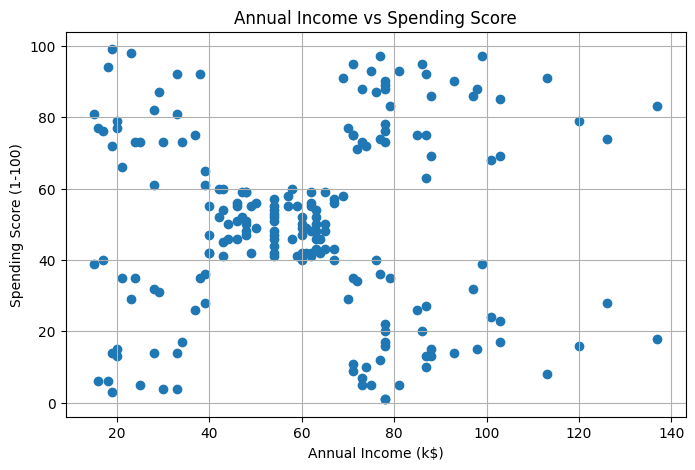

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.scatter(
    df['Annual Income (k$)'],
    df['Spending Score (1-100)']
)
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Annual Income vs Spending Score')
plt.grid(True)
plt.show()

In [ ]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]
print(X.head())

   Annual Income (k$)  Spending Score (1-100)
0                  15                      39
1                  15                      81
2                  16                       6
3                  16                      77
4                  17                      40


In [ ]:

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns
)
print(X_scaled.head())

   Annual Income (k$)  Spending Score (1-100)
0           -1.738999               -0.434801
1           -1.738999                1.195704
2           -1.700830               -1.715913
3           -1.700830                1.040418
4           -1.662660               -0.395980


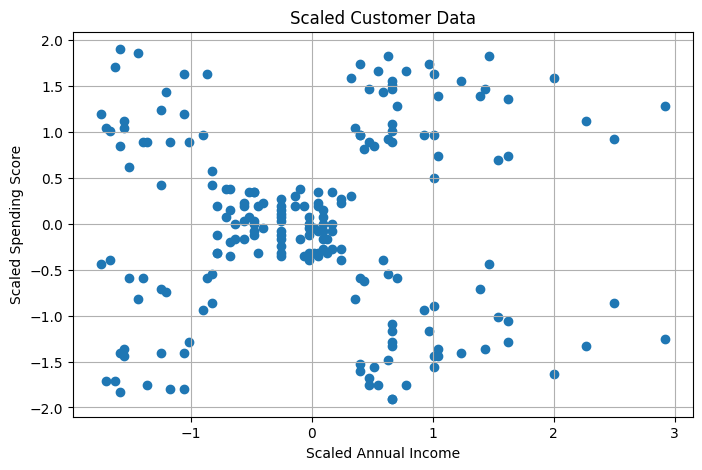

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(
    X_scaled['Annual Income (k$)'],
    X_scaled['Spending Score (1-100)']
)
plt.xlabel('Scaled Annual Income')
plt.ylabel('Scaled Spending Score')
plt.title('Scaled Customer Data')
plt.grid(True)
plt.show()

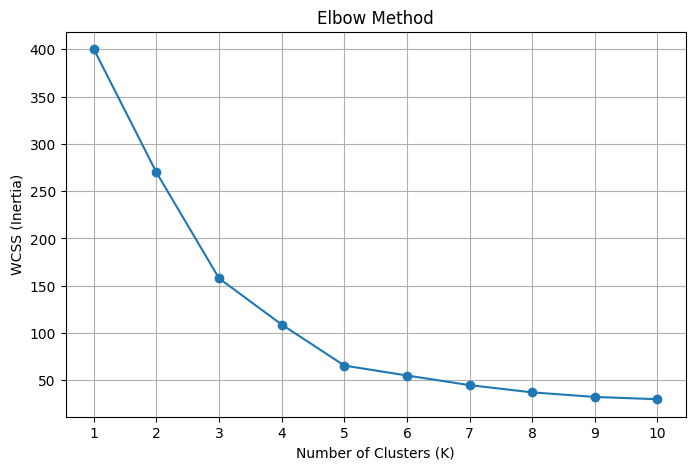

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
wcss = []
for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Inertia)')
plt.title('Elbow Method')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

In [ ]:
from sklearn.metrics import silhouette_score
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"K = {k}, Silhouette Score = {score:.3f}")

K = 2, Silhouette Score = 0.321
K = 3, Silhouette Score = 0.467
K = 4, Silhouette Score = 0.494
K = 5, Silhouette Score = 0.555
K = 6, Silhouette Score = 0.540
K = 7, Silhouette Score = 0.528
K = 8, Silhouette Score = 0.455
K = 9, Silhouette Score = 0.457
K = 10, Silhouette Score = 0.443


In [ ]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
clustered_df = X.copy()
clustered_df['Cluster'] = kmeans.fit_predict(X_scaled)
clustered_df.head()

,Annual Income (k$),Spending Score (1-100),Cluster
0,15,39,4
1,15,81,2
2,16,6,4
3,16,77,2
4,17,40,4


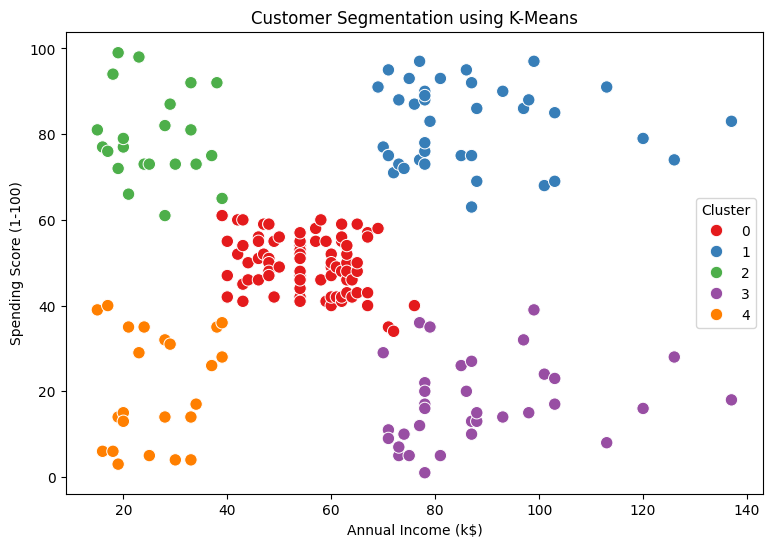

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=clustered_df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    palette='Set1',
    s=80
)
plt.title('Customer Segmentation using K-Means')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.show()

In [ ]:
cluster_summary = clustered_df.groupby('Cluster')[
    ['Annual Income (k$)', 'Spending Score (1-100)']
].mean().round(2)
cluster_summary['Customer Count'] = clustered_df.groupby('Cluster').size()
print(cluster_summary)

         Annual Income (k$)  Spending Score (1-100)  Customer Count
Cluster                                                            
0                     55.30                   49.52              81
1                     86.54                   82.13              39
2                     25.73                   79.36              22
3                     88.20                   17.11              35
4                     26.30                   20.91              23


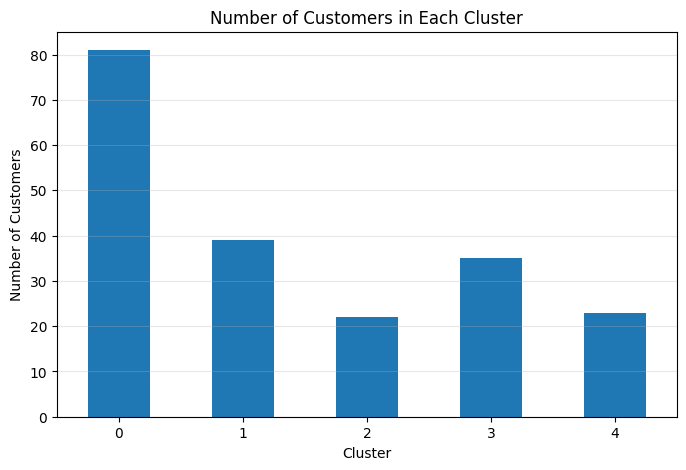

In [ ]:
cluster_counts = clustered_df['Cluster'].value_counts().sort_index()
plt.figure(figsize=(8, 5))
cluster_counts.plot(kind='bar')
plt.title('Number of Customers in Each Cluster')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.show()

In [ ]:
cluster_summary = clustered_df.groupby('Cluster').agg({
    'Annual Income (k$)': 'mean',
    'Spending Score (1-100)': 'mean'
}).round(2)
cluster_summary['Customer Count'] = clustered_df.groupby('Cluster').size()
cluster_summary['Percentage'] = (
    cluster_summary['Customer Count'] / len(clustered_df) * 100
).round(2)
print(cluster_summary)

         Annual Income (k$)  Spending Score (1-100)  Customer Count  \
Cluster                                                               
0                     55.30                   49.52              81   
1                     86.54                   82.13              39   
2                     25.73                   79.36              22   
3                     88.20                   17.11              35   
4                     26.30                   20.91              23   

         Percentage  
Cluster              
0              40.5  
1              19.5  
2              11.0  
3              17.5  
4              11.5  
